### **Experiments for N-dim convex optimization problem**

We have trained more adaptive learning rate (LR) models for Gradient Descent models to be used in higher dimensions: **[5, 10, 100, 800]**

800 is the maximum value because we need the measurement to align with the number of parameters in the MNIST problem

In [1]:
import gymnasium as gym
import numpy as np

import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

import src.gymnasium_envs.convex_optimization_env
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from src.optimization.convex_function import ConvexFunction
from src.optimization.optimization_methods import gradient_descent_optimizer, adam_optimizer

seed = 0

available_dims = [5, 10, 100, 800]

Lets define a function that plots comparison of adaptive algorithm with standard methods

In [2]:
def get_algorithm_result(dim : int, seed : int):
    # Initialize environment
    env = make_vec_env(
        "convex_optimization_env/ConvexOptimization-v0",
        n_envs=1,
        seed=seed,
        env_kwargs={
            "render_mode": "ansi",
            "in_features": dim
        }
    )
    env = VecNormalize.load(f"../models/{dim}d_convex_optimization_vec_normalize_stats.pkl", env)
    env.training = False
    env.norm_reward = False 

    # Load model
    model = PPO.load(f"../models/{dim}d_convex_optimization", env=env, seed=seed)

    obs = env.reset()
    x0 = env.envs[0].unwrapped.get_x_start()

    # Using adaptive algorithm
    done = False

    rl_gd_info = []

    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, info = env.step(action)
        rl_gd_info.append(info)
        done = terminated
    
    # Using standart algorithms
    function1 = ConvexFunction(in_features=dim, random_state=seed)

    gd_info = []
    adam_info = []

    gradient_descent_optimizer(function1, x0=x0, opt_info=gd_info)
    adam_optimizer(function1, x0=x0, opt_info=adam_info)

    # Store result

    gd_it, gd_val = zip(*[(item['iteration'], item['function_value']) for item in gd_info])
    adam_it, adam_val = zip(*[(item['iteration'], item['function_value']) for item in adam_info])
    rl_gd_it, rl_gd_val = zip(*[(item[0]['iteration'], item[0]['function_value']) for item in rl_gd_info[:-2]])

    return {
        "Gradient Descent" : (gd_it, gd_val),
        "ADAM" : (adam_it, adam_val),
        "GD with adaptive LR" : (rl_gd_it, rl_gd_val)
    }

def plot_converging_comparasion(result : dict, dim : int):
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    for name, values in result.items():
        sns.lineplot(x=values[0], y=values[1], label=name)

    plt.title(f'Convex optimization task (n_features={dim}): ADAM vs GD vs GD with adaptive LR')
    plt.xlabel('Iteration')
    plt.ylabel('Function Value')
    plt.legend()
    plt.show()

def plot_comparasion_table(result : dict):
    table_data = [{
        "Name" : name,
        "Iteration count" : len(values[0]),
        "Function value" : values[1][-1]
        } 
    for name, values in result.items()]
    
    df = pd.DataFrame(table_data)

    display(df)

Now we'll plot comparasion on higher dimensions

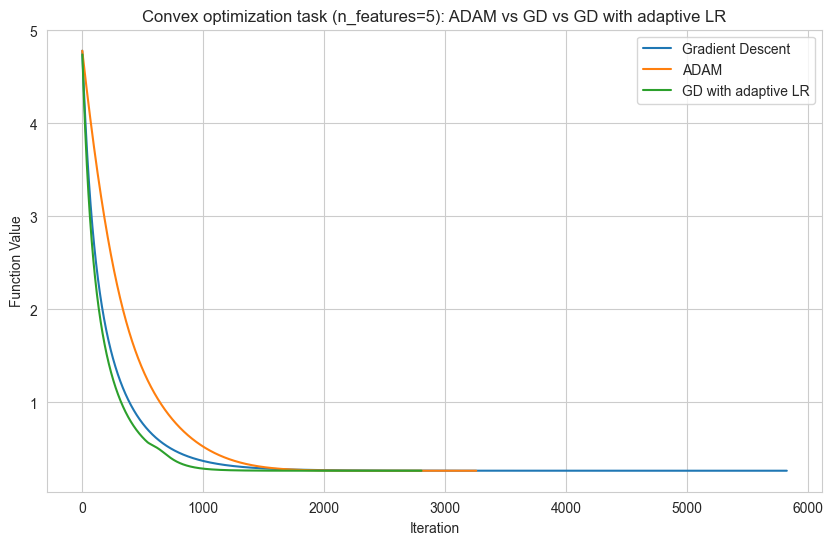

,Name,Iteration count,Function value
0,Gradient Descent,5829,0.264556
1,ADAM,3260,0.264556
2,GD with adaptive LR,2806,0.264556


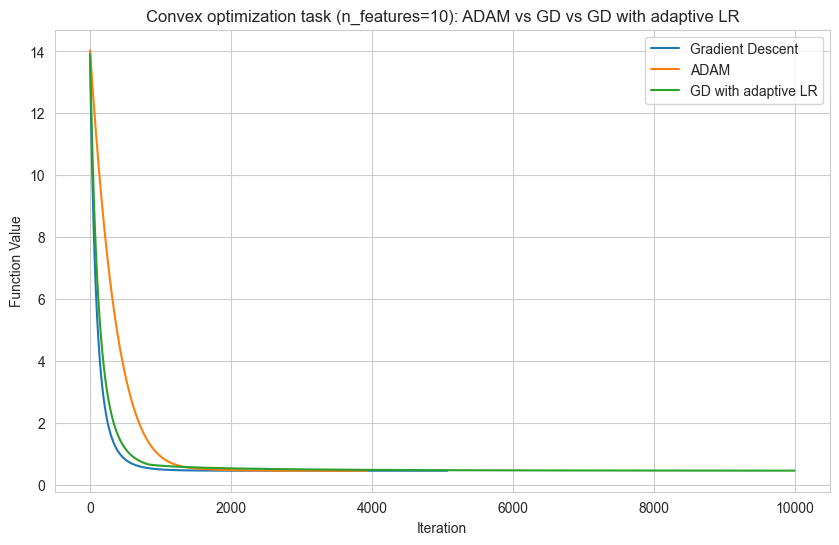

,Name,Iteration count,Function value
0,Gradient Descent,5073,0.447126
1,ADAM,3928,0.447126
2,GD with adaptive LR,9999,0.449326


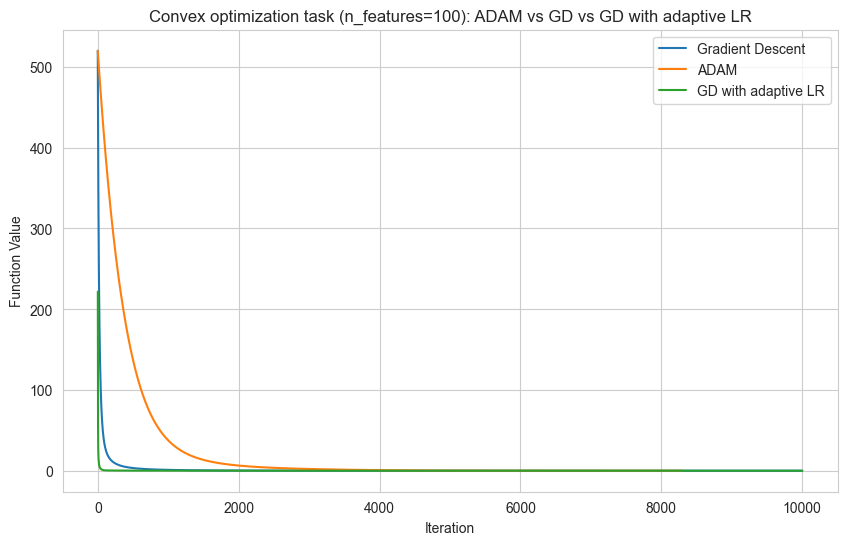

,Name,Iteration count,Function value
0,Gradient Descent,10001,0.577756
1,ADAM,8290,0.577679
2,GD with adaptive LR,9999,0.580539


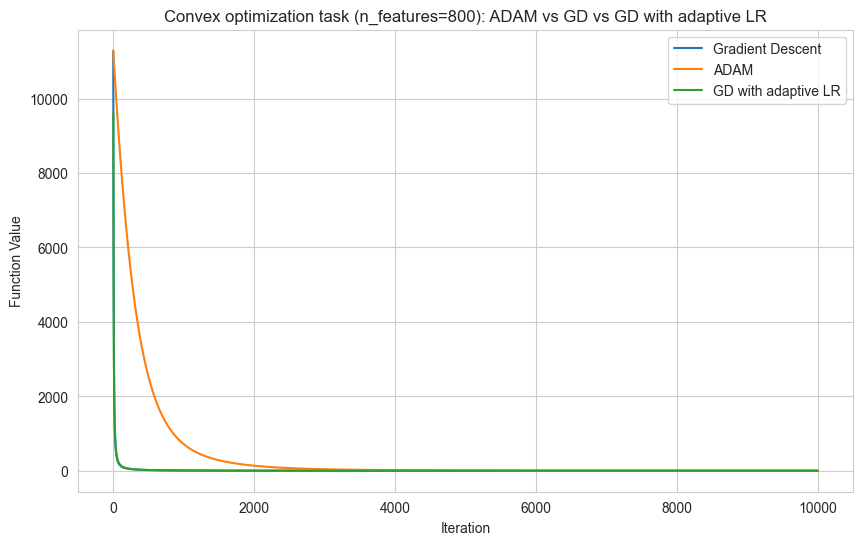

,Name,Iteration count,Function value
0,Gradient Descent,10001,0.341458
1,ADAM,10001,0.323990
2,GD with adaptive LR,9999,0.295702


In [3]:
for dim in available_dims:
    result = get_algorithm_result(dim=dim, seed=seed)
    
    plot_converging_comparasion(result, dim)
    plot_comparasion_table(result)
    

Now lets look at the distribution of the number of iterations for the algorithm

In [4]:
sample_count = 10

for dim in available_dims:
    print(f"Distribution of iterations number on {dim}-dim convex problem")

    rng = np.random.default_rng(seed)

    data = {}

    for i in range(sample_count):
        sub_seed = int(rng.integers(low=0, high=np.iinfo(np.uint32).max))
        result = get_algorithm_result(dim, sub_seed)

        if i == 0:
            for name, values in result.items():
                data.setdefault(name, [len(values[0])])
            continue
        
        for name, values in result.items():
            data[name].append(len(values[0]))

    stats = pd.DataFrame({
        algo: {
            'mean': np.mean(vals),
            'variance': np.var(vals),
            'std': np.std(vals),
            'min': np.min(vals),
            'max': np.max(vals),
            'range': np.ptp(vals)
        }
        for algo, vals in data.items()
    }).T.round(2)

    display(stats)

Distribution of iterations number on 5-dim convex problem


,mean,variance,std,min,max,range
Gradient Descent,5131.9,354397.69,595.31,3732.0,5959.0,2227.0
ADAM,3623.3,586344.01,765.73,2396.0,4701.0,2305.0
GD with adaptive LR,2435.2,70784.76,266.05,1806.0,2723.0,917.0


Distribution of iterations number on 10-dim convex problem


,mean,variance,std,min,max,range
Gradient Descent,5997.0,342436.40,585.18,5154.0,7019.0,1865.0
ADAM,4399.9,374894.69,612.29,3438.0,5513.0,2075.0
GD with adaptive LR,9999.0,0.00,0.00,9999.0,9999.0,0.0


Distribution of iterations number on 100-dim convex problem


,mean,variance,std,min,max,range
Gradient Descent,10001.0,0.00,0.0,10001.0,10001.0,0.0
ADAM,8480.9,101699.69,318.9,7969.0,8964.0,995.0
GD with adaptive LR,9999.0,0.00,0.0,9999.0,9999.0,0.0


Distribution of iterations number on 800-dim convex problem


,mean,variance,std,min,max,range
Gradient Descent,10001.0,0.00,0.00,10001.0,10001.0,0.0
ADAM,10001.0,0.00,0.00,10001.0,10001.0,0.0
GD with adaptive LR,7998.9,2923025.09,1709.69,5785.0,9999.0,4214.0
